# Assignment 2: Credit, Derivative, Liquidity & Operational Risk

Same three companies as before, AAPL, PFE and XOM. The data is a dated snapshot and every simulation is seeded, so this reproduces.

In [1]:
import os, warnings, itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, skew, kurtosis
from scipy.optimize import fsolve
from IPython.display import display
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
BLUE, RED, GREEN, GOLD = '#2C7BB6', '#D7191C', '#1A9641', '#F39C12'

STOCKS = ['AAPL', 'PFE', 'XOM']
RF, LGD, RECOV = 0.04, 0.45, 0.55

px   = pd.read_csv('../A1/my_portfolio.csv', index_col=0, parse_dates=True)
rets = np.log(px / px.shift(1)).dropna()
SIGMA_E = (rets[STOCKS].std() * np.sqrt(252)).to_dict()

W        = np.array([1/3, 1/3, 1/3])
r_port   = px[STOCKS].pct_change().dropna() @ W
var_base = -(r_port.mean() + stats.norm.ppf(0.01) * r_port.std())

E      = {'AAPL': 4.660445e12, 'PFE': 1.395224e11, 'XOM': 5.989863e11}
D      = {'AAPL': 8.4711e10,   'PFE': 6.4731e10,   'XOM': 4.7661e10}
PRICE  = {'AAPL': 317.31, 'PFE': 24.48, 'XOM': 144.51}
RATING = {'AAPL': 'AA+',  'PFE': 'A',   'XOM': 'AA-'}
SPREAD = {'AAPL': 0.0035, 'PFE': 0.0070, 'XOM': 0.0045}
RATING_PD = {'AA+': 0.0002, 'AA-': 0.0002, 'A': 0.0005}

print('Equity vol:', {k: round(v, 3) for k, v in SIGMA_E.items()})
print(f'Portfolio 1-day 99% VaR: {var_base*100:.2f}%')
print(f'\nPrice sample ends {px.index[-1].date()}. Hand-entered Merton inputs, '
      f'against that close:')
for s in STOCKS:
    print(f'  {s:5s} market cap ${E[s]/1e12:.2f}tn   total debt ${D[s]/1e9:.1f}bn   '
          f'spot ${PRICE[s]:.2f}   last close in sample ${px[s].iloc[-1]:.2f}')

Equity vol: {'AAPL': 0.262, 'PFE': 0.242, 'XOM': 0.233}
Portfolio 1-day 99% VaR: 2.32%

Price sample ends 2026-06-30. Hand-entered Merton inputs, against that close:
  AAPL  market cap $4.66tn   total debt $84.7bn   spot $317.31   last close in sample $289.36
  PFE   market cap $0.14tn   total debt $64.7bn   spot $24.48   last close in sample $24.08
  XOM   market cap $0.60tn   total debt $47.7bn   spot $144.51   last close in sample $136.72


## 1 · Merton structural model & default probability

Equity is a call on the firm's assets struck at the debt face. I cannot see the assets, so I solve the two Merton equations for asset value and volatility from E, my equity volatility and D, giving the distance-to-default and PD = N(-DD). E and D are each firm's market cap and total debt from Yahoo, pulled just after the close ending my return series, so AAPL's $4.66tn cap sits on a $317.31 spot not the $289.36 my sample ends on, deliberate since Merton wants today's equity but the volatility spans three years. Ratings are S&P grades and the spreads indicative, not quoted CDS.

Three approximations bend the PD. The risk-free rate stands in for the asset drift, so my PD is risk-neutral and above the real-world frequency, and total debt as the barrier is conservative. But the debt is one zero-coupon bond maturing in a year, so default can only strike then.

,Rating,Spread (bp),Leverage %,Asset vol,DD (Merton),PD Merton,PD rating,PD CDS,DD implied by CDS
Firm,,,,,,,,,
AAPL,AA+,35.0,1.8,0.258,15.66,1.52e-55,0.020%,0.778%,2.42
PFE,A,70.0,31.7,0.167,6.96,1.74e-12,0.050%,1.556%,2.16
XOM,AA-,45.0,7.4,0.216,12.13,3.88e-34,0.020%,1.000%,2.33


The same firm, three PD measures (1-year):
  AAPL  Merton 1.52e-55   rating 0.020%   CDS 0.778%   |  DD: model 15.7 sigma vs CDS-implied 2.4 sigma
  PFE   Merton 1.74e-12   rating 0.050%   CDS 1.556%   |  DD: model 7.0 sigma vs CDS-implied 2.2 sigma
  XOM   Merton 3.88e-34   rating 0.020%   CDS 1.000%   |  DD: model 12.1 sigma vs CDS-implied 2.3 sigma


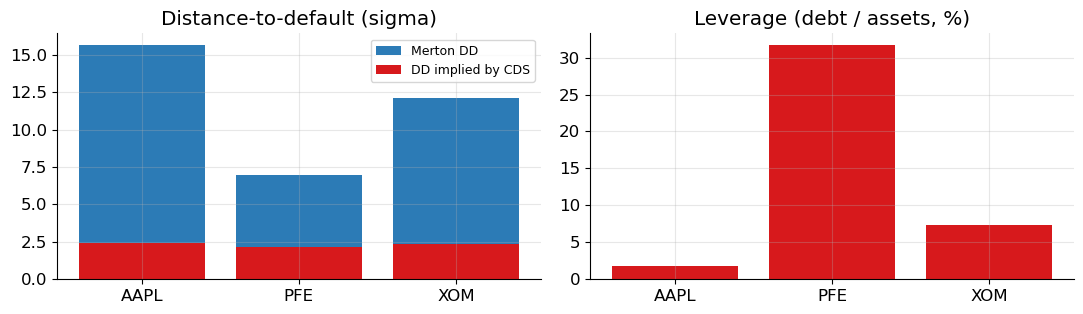

In [2]:
def merton_calibrate(E_obs, sigma_E, D_face, r=RF, T=1.0):
    def eqs(x):
        V, sV = x
        d1 = (np.log(V/D_face) + (r + 0.5*sV**2)*T) / (sV*np.sqrt(T))
        d2 = d1 - sV*np.sqrt(T)
        return [V*norm.cdf(d1) - D_face*np.exp(-r*T)*norm.cdf(d2) - E_obs,
                norm.cdf(d1)*sV*V - sigma_E*E_obs]
    V, sV = fsolve(eqs, [E_obs + D_face, sigma_E*E_obs/(E_obs+D_face)])
    dd = (np.log(V/D_face) + (r - 0.5*sV**2)*T) / (sV*np.sqrt(T))
    return V, sV, dd, norm.cdf(-dd)

rows = []
for s in STOCKS:
    V, sV, dd, pd_ = merton_calibrate(E[s], SIGMA_E[s], D[s])
    cds_pd, rat_pd = SPREAD[s]/(1-RECOV), RATING_PD[RATING[s]]
    rows.append({'Firm': s, 'Rating': RATING[s], 'Spread (bp)': SPREAD[s]*1e4,
                 'Leverage %': D[s]/(E[s]+D[s])*100,
                 'Asset vol': sV, 'DD (Merton)': dd, 'PD Merton': pd_,
                 'PD rating': rat_pd, 'PD CDS': cds_pd,
                 'DD implied by CDS': -norm.ppf(cds_pd)})
merton_df = pd.DataFrame(rows).set_index('Firm')

show = merton_df.round({'Spread (bp)': 0, 'Leverage %': 1, 'Asset vol': 3,
                        'DD (Merton)': 2, 'DD implied by CDS': 2})
show['PD Merton'] = merton_df['PD Merton'].map('{:.2e}'.format)
show['PD rating'] = merton_df['PD rating'].map('{:.3%}'.format)
show['PD CDS']    = merton_df['PD CDS'].map('{:.3%}'.format)
display(show)

print('The same firm, three PD measures (1-year):')
for s in STOCKS:
    r_ = merton_df.loc[s]
    print(f"  {s:5s} Merton {r_['PD Merton']:.2e}   rating {r_['PD rating']:.3%}   "
          f"CDS {r_['PD CDS']:.3%}   |  DD: model {r_['DD (Merton)']:.1f} sigma vs "
          f"CDS-implied {r_['DD implied by CDS']:.1f} sigma")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].bar(STOCKS, [merton_df.loc[s, 'DD (Merton)'] for s in STOCKS], color=BLUE, label='Merton DD')
ax[0].bar(STOCKS, [merton_df.loc[s, 'DD implied by CDS'] for s in STOCKS], color=RED,
          label='DD implied by CDS')
ax[0].set_title('Distance-to-default (sigma)'); ax[0].legend(fontsize=9)
ax[1].bar(STOCKS, [D[s]/(E[s]+D[s])*100 for s in STOCKS], color=RED)
ax[1].set_title('Leverage (debt / assets, %)')
plt.tight_layout(); plt.show()

**Interpretation:** My structural PDs are microscopic. PFE is highest at about 1.7e-12 because it carries the most leverage, debt near 32% of assets, while AAPL sits 15.7 sigma out at around 1e-55.

For AAPL the market charges a 35bp spread, implying a 0.78% one-year PD, the rating tables put an AA+ default at about 0.02%, and Merton says 1e-55. So the market prices AAPL as if 2.4 sigma from default while Merton puts it 15.7 sigma out. The CDS number is too high because dividing the whole spread by one minus recovery blames it all on default, when much of a spread is risk premium and illiquidity.

Both my risk-neutral PDs should top the table's real-world 0.02%, and the CDS PD does at 0.78%, but Merton's 1e-55 sits far below, so the thin Normal tail swamps a bias that should have pushed it up. Real firms gap into default while this model only lets them drift.

## 2 · Loan book & Monte-Carlo portfolio loss

I run on the CDS-implied PDs. The structural ones are too small to lose anything worth simulating.

     EAD weight PD (CDS-implied)
AAPL      43.0%           0.778%
PFE       32.8%           1.556%
XOM       24.2%           1.000%
Expected loss: 0.489% of book  |  EAD-weighted avg PD: 1.09%

3-name concentrated book. Credit VaR nets off expected loss, and
economic capital is the 99.9% Credit VaR:
    rho    VaR99  VaR99.9   CVaR99  CVaR99.9    ES99   ES99.9
   0.05   14.78%   19.34%   14.29%    18.85%  16.62%   20.02%
   0.15   14.78%   19.34%   14.29%    18.85%  16.82%   20.48%
   0.30   14.78%   30.22%   14.29%    29.73%  17.35%   33.39%

Every possible outcome of a 3-name book (loss atoms and their probability %):
  defaults            loss    rho=0.05    rho=0.15     rho=0.3
  ------------------------------------------------------------


  AAPL + PFE + XOM  45.00%      0.000%      0.002%      0.008%
  AAPL + PFE        34.12%      0.017%      0.029%      0.056%
  AAPL + XOM        30.22%      0.011%      0.019%      0.039%
  PFE + XOM         25.66%      0.019%      0.036%      0.073%
  AAPL              19.34%      0.747%      0.722%      0.670%


  PFE               14.78%      1.517%      1.487%      1.411%
  XOM               10.88%      0.964%      0.944%      0.880%
  none               0.00%     96.726%     96.760%     96.862%

Granular homogeneous pool (N=1000 at avg PD) vs Vasicek analytic:
   rho   sim VaR99.9  Vasicek99.9


  0.05         2.39%        2.25%


  0.15         5.45%        5.26%


  0.30        10.89%       10.61%

The same analytic ASRF capital, name by name on my actual three, against
the simulated 3-name economic capital (both 99.9%, net of expected loss):
   rho  sim EC (3 names)  ASRF EC (3 names)
  0.05            18.85%              1.74%
  0.15            18.85%              4.70%
  0.30            29.73%              9.96%


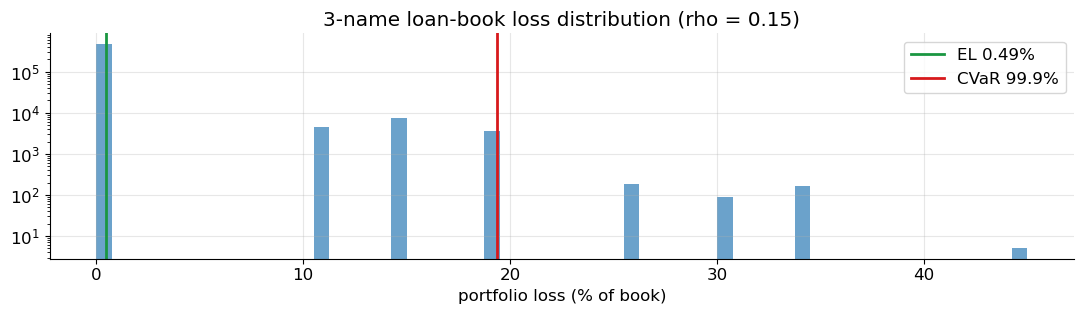

In [3]:
book = pd.DataFrame(index=STOCKS)
book['EAD weight']       = np.array([D[s] for s in STOCKS]); book['EAD weight'] /= book['EAD weight'].sum()
book['PD (CDS-implied)'] = [SPREAD[s]/(1-RECOV) for s in STOCKS]
EAD, PD = book['EAD weight'].values, book['PD (CDS-implied)'].values
EL, pdbar = (EAD*LGD*PD).sum(), (EAD*PD).sum()

disp = book.copy()
disp['EAD weight']       = disp['EAD weight'].map('{:.1%}'.format)
disp['PD (CDS-implied)'] = disp['PD (CDS-implied)'].map('{:.3%}'.format)
print(disp.to_string())
print(f'Expected loss: {EL*100:.3f}% of book  |  EAD-weighted avg PD: {pdbar*100:.2f}%')

def simulate_portfolio_loss(PD, EAD, LGD, rho, n=500_000, seed=42, matrix=False):
    g = np.random.default_rng(seed)
    A = np.sqrt(rho)*g.standard_normal((n, 1)) + np.sqrt(1-rho)*g.standard_normal((n, len(PD)))
    Dmat = A < norm.ppf(PD)
    return Dmat if matrix else (Dmat * EAD * LGD).sum(axis=1)

def vasicek_var(conf, PD, LGD, rho):
    num = norm.ppf(PD) + np.sqrt(rho) * norm.ppf(conf)
    cond_pd = norm.cdf(num / np.sqrt(1 - rho))
    return cond_pd * LGD

RHOS = [0.05, 0.15, 0.30]
print('\n3-name concentrated book. Credit VaR nets off expected loss, and')
print('economic capital is the 99.9% Credit VaR:')
print(f"  {'rho':>5}{'VaR99':>9}{'VaR99.9':>9}{'CVaR99':>9}{'CVaR99.9':>10}{'ES99':>8}{'ES99.9':>9}")
loss_show = None
for rho in RHOS:
    L = simulate_portfolio_loss(PD, EAD, LGD, rho)
    v99, v999 = np.percentile(L, 99), np.percentile(L, 99.9)
    print(f'  {rho:>5.2f}{v99*100:8.2f}%{v999*100:8.2f}%{(v99-EL)*100:8.2f}%{(v999-EL)*100:9.2f}%'
          f'{L[L>=v99].mean()*100:7.2f}%{L[L>=v999].mean()*100:8.2f}%')
    if rho == 0.15: loss_show = L

print('\nEvery possible outcome of a 3-name book (loss atoms and their probability %):')
hdr = f"  {'defaults':<16}{'loss':>8}" + ''.join(f'{"rho="+str(r):>12}' for r in RHOS)
print(hdr); print('  ' + '-'*(len(hdr)-2))
Dmats = {rho: simulate_portfolio_loss(PD, EAD, LGD, rho, n=2_000_000, seed=1, matrix=True)
         for rho in RHOS}
atoms = []
for combo in itertools.product([0, 1], repeat=3):
    nm = ' + '.join(s for s, c in zip(STOCKS, combo) if c) or 'none'
    atoms.append((nm, np.array(combo), (np.array(combo)*EAD*LGD).sum()))
for nm, combo, loss in sorted(atoms, key=lambda a: -a[2]):
    ps = [np.all(Dmats[rho] == combo, axis=1).mean()*100 for rho in RHOS]
    print(f'  {nm:<16}{loss*100:7.2f}%' + ''.join(f'{p:>11.3f}%' for p in ps))

print('\nGranular homogeneous pool (N=1000 at avg PD) vs Vasicek analytic:')
print(f"  {'rho':>4} {'sim VaR99.9':>13} {'Vasicek99.9':>12}")
PDp, EADp = np.full(1000, pdbar), np.full(1000, 1/1000)
for rho in RHOS:
    L = simulate_portfolio_loss(PDp, EADp, LGD, rho, n=200_000)
    print(f"  {rho:>4.2f} {np.percentile(L,99.9)*100:12.2f}% {vasicek_var(0.999,pdbar,LGD,rho)*100:11.2f}%")

print('\nThe same analytic ASRF capital, name by name on my actual three, against')
print('the simulated 3-name economic capital (both 99.9%, net of expected loss):')
print(f"  {'rho':>4} {'sim EC (3 names)':>17} {'ASRF EC (3 names)':>18}")
for rho in RHOS:
    L = simulate_portfolio_loss(PD, EAD, LGD, rho)
    sim_ec  = np.percentile(L, 99.9) - EL
    asrf_ec = sum((vasicek_var(0.999, PD[i], LGD, rho) - LGD*PD[i]) * EAD[i]
                  for i in range(len(PD)))
    print(f"  {rho:>4.2f} {sim_ec*100:>16.2f}% {asrf_ec*100:>17.2f}%")

fig, ax = plt.subplots(figsize=(11, 3.3))
ax.hist(loss_show*100, bins=60, color=BLUE, alpha=.7)
ax.axvline(EL*100, color=GREEN, lw=2, label=f'EL {EL*100:.2f}%')
ax.axvline(np.percentile(loss_show,99.9)*100, color=RED, lw=2, label='CVaR 99.9%')
ax.set_yscale('log'); ax.set_xlabel('portfolio loss (% of book)')
ax.set_title('3-name loan-book loss distribution (rho = 0.15)'); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation:** Expected loss is tiny at 0.489% of the book but the tail is brutal, and the reason is concentration. One PFE default alone costs 14.78%, so the 99% VaR sits there, a 14.29% Credit VaR net of expected loss. Economic capital, the 99.9% Credit VaR, runs from 18.85% to 29.73%, and ES is blunter, the rho = 0.30 99.9% ES at 33.39% against a 30.22% VaR. A thousand-borrower pool tracks Vasicek closely (2.39/5.45/10.89% against 2.25/5.26/10.61%), but run name by name on my actual three that same analytic formula asks only 4.70% of capital at rho = 0.15 against the 18.85% my simulation needs, and that gap is the concentration premium the granular IRB charge cannot see.

The surprise is the 99% VaR frozen at 14.78% for every correlation. Three names make only eight atoms, so PFE alone holds my whole 1% tail whatever correlation does. Raising rho from 0.05 to 0.30 barely moves the single-default atoms (PFE 1.517% to 1.411%) but more than triples the joint ones (AAPL and PFE 0.017% to 0.056%), so once that mass clears 0.1% the 99.9% quantile leaves AAPL alone at 19.34% and jumps to AAPL and XOM at 30.22%.

The Gaussian factor may be too thin in a crisis, so I test it, keeping the PDs and correlations and swapping only the common factor for a Student-t with 4 degrees of freedom, plus a rho of 0.60. I also run the book on the structural PDs, floored at the rating table where Merton is effectively zero.

In [4]:
NU_T, CRISIS_RHO = 4, 0.60

def simulate_portfolio_loss_t(PD, EAD, LGD, rho, nu=NU_T, n=500_000, seed=42, matrix=False):
    g = np.random.default_rng(seed)
    Z = np.sqrt(rho)*g.standard_normal((n, 1)) + np.sqrt(1-rho)*g.standard_normal((n, len(PD)))
    A = Z * np.sqrt(nu / g.chisquare(nu, (n, 1)))
    Dmat = A < stats.t.ppf(PD, nu)
    return Dmat if matrix else (Dmat * EAD * LGD).sum(axis=1)

print(f'Same PDs, same correlation, one factor swapped for a Student-t with nu = {NU_T}:')
print(f"  {'rho':>6}{'P(2+ defaults) gauss':>22}{'t':>10}{'ratio':>8}"
      f"{'VaR99.9 gauss':>15}{'VaR99.9 t':>11}")
for rho in RHOS + [CRISIS_RHO]:
    d_gauss = simulate_portfolio_loss(PD, EAD, LGD, rho, n=2_000_000, seed=1, matrix=True)
    d_t     = simulate_portfolio_loss_t(PD, EAD, LGD, rho, n=2_000_000, seed=1, matrix=True)
    p_gauss, p_t = (d_gauss.sum(1) >= 2).mean(), (d_t.sum(1) >= 2).mean()
    L_gauss, L_t = (d_gauss*EAD*LGD).sum(1), (d_t*EAD*LGD).sum(1)
    tag = '  <- crisis' if rho == CRISIS_RHO else ''
    print(f'  {rho:>6.2f}{p_gauss*100:>21.3f}%{p_t*100:>9.3f}%{p_t/p_gauss:>7.1f}x'
          f'{np.percentile(L_gauss,99.9)*100:>14.2f}%{np.percentile(L_t,99.9)*100:>10.2f}%{tag}')

pd_floored = np.array([max(merton_df.loc[s, 'PD Merton'], RATING_PD[RATING[s]]) for s in STOCKS])
print('\nThe same book run on the structural PDs, floored at the rating table where')
print('Merton returns effectively zero (' + ', '.join(f'{s} {p:.2%}' for s, p
                                                      in zip(STOCKS, pd_floored)) + '):')
print(f"  {'rho':>6}{'EL':>10}{'P(any default)':>17}{'VaR99':>9}{'VaR99.9':>10}")
for rho in RHOS:
    L = simulate_portfolio_loss(pd_floored, EAD, LGD, rho, n=2_000_000, seed=42)
    print(f'  {rho:>6.2f}{(EAD*LGD*pd_floored).sum()*100:>9.3f}%{(L>0).mean()*100:>16.3f}%'
          f'{np.percentile(L,99)*100:>8.2f}%{np.percentile(L,99.9)*100:>9.2f}%')

Same PDs, same correlation, one factor swapped for a Student-t with nu = 4:
     rho  P(2+ defaults) gauss         t   ratio  VaR99.9 gauss  VaR99.9 t


    0.05                0.047%    0.306%    6.5x         19.34%     34.12%


    0.15                0.086%    0.364%    4.2x         19.34%     34.12%


    0.30                0.176%    0.468%    2.7x         30.22%     34.12%


    0.60                0.467%    0.696%    1.5x         34.12%     45.00%  <- crisis

The same book run on the structural PDs, floored at the rating table where
Merton returns effectively zero (AAPL 0.02%, PFE 0.05%, XOM 0.02%):
     rho        EL   P(any default)    VaR99   VaR99.9
    0.05    0.013%           0.089%    0.00%     0.00%
    0.15    0.013%           0.088%    0.00%     0.00%


    0.30    0.013%           0.090%    0.00%     0.00%


**Interpretation:** Swapping the factor does more than raising correlation. At rho = 0.05 the t makes two or more defaults 6.5 times more likely than the Gaussian, and my 99.9% VaR jumps from 19.34% to 34.12%, the AAPL and PFE atom the Gaussian only reaches at rho = 0.30. So a fatter tail buys more capital than tripling correlation.

The surprise is the ratio shrinking as correlation rises, from 6.5x at rho = 0.05 to 1.5x at 0.60. The t adds most where the Gaussian is most confident, so the two are substitutes not additions, and stressing only rho would have said the copula hardly matters. At rho = 0.60 the t still finds the all-three atom at 45.00%.

On the floored structural PDs my book expects to lose 0.013% and sees any default just 0.089% of the time, so both VaRs are zero, the quantile blind to anything rarer than one in a thousand. Same book and copula, my capital is either nothing or a third of the book depending only on which PD I believe.

## 3 · Derivatives, pricing, Greeks & VaR

I shock the spot only and hold time fixed, so the VaR isolates what delta and gamma describe.

3-month ATM AAPL call | S0 = K = $317.31, sigma = 26.2%, r = 4%
Black-Scholes: $18.1170

CRR binomial convergence to Black-Scholes:
  N=    5   CRR $ 18.9468   error  +0.8298
  N=   10   CRR $ 17.7093   error  -0.4077
  N=   25   CRR $ 18.2807   error  +0.1638
  N=   50   CRR $ 18.0345   error  -0.0825
  N=  100   CRR $ 18.0757   error  -0.0413
  N=  250   CRR $ 18.1004   error  -0.0165
  N=  500   CRR $ 18.1087   error  -0.0083
  N= 2000   CRR $ 18.1149   error  -0.0021


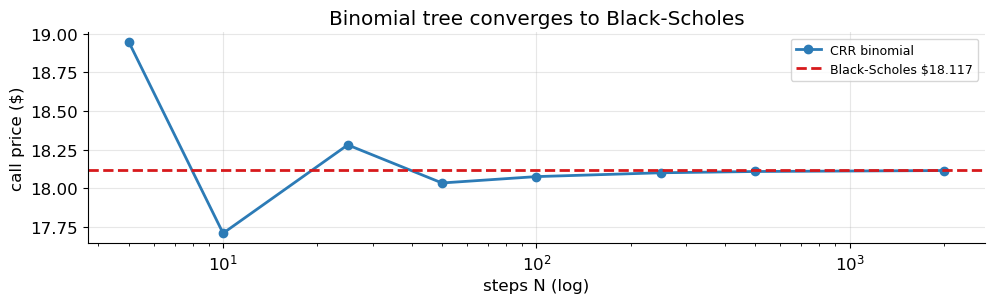

In [5]:
def bs_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    d1, d2 = bs_d1(S, K, T, r, sigma), bs_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, r, sigma, option='call'):
    d1 = bs_d1(S, K, T, r, sigma)
    if option == 'call':
        return norm.cdf(d1)
    return norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T) / 100

def bs_theta(S, K, T, r, sigma, option='call'):
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = bs_d2(S, K, T, r, sigma)
    term1 = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option == 'call':
        return (term1 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    return (term1 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

def crr_price(S, K, T, r, sigma, N, option='call', style='european'):
    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    p    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    j       = np.arange(N + 1)
    ST      = S * u**j * d**(N - j)

    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    for i in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if style == 'american':
            S_i = S * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
            if option == 'call':
                V = np.maximum(V, S_i - K)
            else:
                V = np.maximum(V, K - S_i)
    return V[0]

S0, K, T_OPT, SIG = PRICE['AAPL'], PRICE['AAPL'], 0.25, SIGMA_E['AAPL']
call_bs = bs_call(S0, K, T_OPT, RF, SIG)
print(f'3-month ATM AAPL call | S0 = K = ${S0:.2f}, sigma = {SIG:.1%}, r = {RF:.0%}')
print(f'Black-Scholes: ${call_bs:.4f}\n')
print('CRR binomial convergence to Black-Scholes:')
Ns = [5, 10, 25, 50, 100, 250, 500, 2000]
crr = [crr_price(S0, K, T_OPT, RF, SIG, N) for N in Ns]
for N, c in zip(Ns, crr):
    print(f'  N={N:>5}   CRR ${c:8.4f}   error {c-call_bs:+8.4f}')

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(Ns, crr, 'o-', color=BLUE, lw=2, label='CRR binomial')
ax.axhline(call_bs, color=RED, ls='--', lw=2, label=f'Black-Scholes ${call_bs:.3f}')
ax.set_xscale('log'); ax.set_xlabel('steps N (log)'); ax.set_ylabel('call price ($)')
ax.set_title('Binomial tree converges to Black-Scholes'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Greeks: delta 0.5564   gamma 0.00950   vega $0.6266 per +1% vol   theta $-0.1073 per day

Closed-form Greeks against bumping the pricer numerically:
  delta  closed form   0.556395   bumped   0.556395   difference +1.0e-08
  gamma  closed form   0.009500   bumped   0.009500   difference +4.3e-10
  vega   closed form   0.626607   bumped   0.626607   difference +3.3e-10

 horizon  position   full reval   delta-gamma   delta-only   delta-only error
   1-day    long  $      6.06  $       6.08  $      6.78             11.9%
   1-day   short  $      7.48  $       7.50  $      6.79             -9.2%
  10-day    long  $     14.29  $      14.37  $     21.39             49.6%
  10-day   short  $     27.50  $      28.42  $     21.40            -22.2%


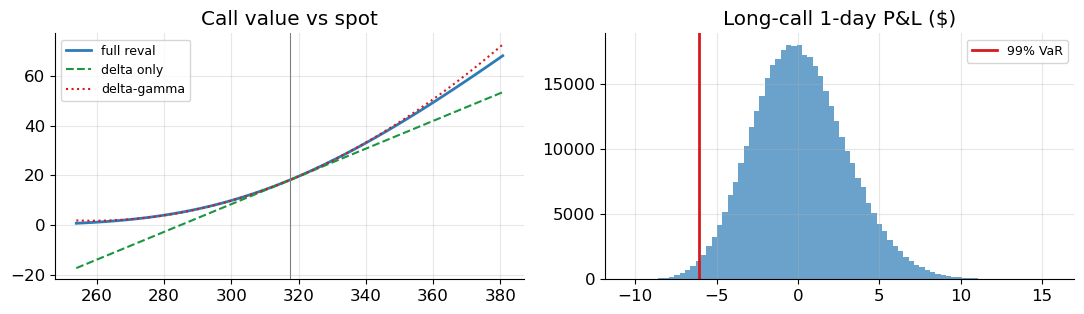

In [6]:
delta = bs_delta(S0, K, T_OPT, RF, SIG)
gamma = bs_gamma(S0, K, T_OPT, RF, SIG)
vega  = bs_vega (S0, K, T_OPT, RF, SIG)
theta = bs_theta(S0, K, T_OPT, RF, SIG)
print(f'Greeks: delta {delta:.4f}   gamma {gamma:.5f}   vega ${vega:.4f} per +1% vol   '
      f'theta ${theta:.4f} per day')

bump_S, bump_sig = S0*1e-4, 1e-4
fd_delta = (bs_call(S0+bump_S, K, T_OPT, RF, SIG) - bs_call(S0-bump_S, K, T_OPT, RF, SIG)) / (2*bump_S)
fd_gamma = (bs_call(S0+bump_S, K, T_OPT, RF, SIG) - 2*call_bs
            + bs_call(S0-bump_S, K, T_OPT, RF, SIG)) / bump_S**2
fd_vega  = (bs_call(S0, K, T_OPT, RF, SIG+bump_sig)
            - bs_call(S0, K, T_OPT, RF, SIG-bump_sig)) / (2*bump_sig) / 100
print('\nClosed-form Greeks against bumping the pricer numerically:')
for nm, closed, bumped in [('delta', delta, fd_delta), ('gamma', gamma, fd_gamma),
                           ('vega', vega, fd_vega)]:
    print(f'  {nm:<6} closed form {closed:>10.6f}   bumped {bumped:>10.6f}   '
          f'difference {closed-bumped:+.1e}')

g = np.random.default_rng(7)
var99 = lambda x: -np.percentile(x, 1)
print(f"\n{'horizon':>8}  {'position':>6}  {'full reval':>11}  {'delta-gamma':>12}  "
      f"{'delta-only':>11}  {'delta-only error':>17}")
for H, lab in [(1, '1-day'), (10, '10-day')]:
    dS = S0 * g.normal(0, SIG*np.sqrt(H/252), 400_000)
    pnl_full = bs_call(S0+dS, K, T_OPT, RF, SIG) - call_bs
    pnl_dg   = delta*dS + 0.5*gamma*dS**2
    pnl_do   = delta*dS
    for sign, nm in [(1, 'long'), (-1, 'short')]:
        f, dg, do = var99(sign*pnl_full), var99(sign*pnl_dg), var99(sign*pnl_do)
        print(f'{lab:>8}  {nm:>6}  ${f:>10.2f}  ${dg:>11.2f}  ${do:>10.2f}  {(do-f)/f:>16.1%}')
    if H == 1: pnl_1d = pnl_full

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
Sg = np.linspace(S0*.8, S0*1.2, 120)
ax[0].plot(Sg, bs_call(Sg, K, T_OPT, RF, SIG), color=BLUE, lw=2, label='full reval')
ax[0].plot(Sg, call_bs + delta*(Sg-S0), color=GREEN, ls='--', label='delta only')
ax[0].plot(Sg, call_bs + delta*(Sg-S0) + 0.5*gamma*(Sg-S0)**2, color=RED, ls=':', label='delta-gamma')
ax[0].axvline(S0, color='gray', lw=.8); ax[0].set_title('Call value vs spot'); ax[0].legend(fontsize=9)
ax[1].hist(pnl_1d, bins=80, color=BLUE, alpha=.7)
ax[1].axvline(-var99(pnl_1d), color=RED, lw=2, label='99% VaR')
ax[1].set_title('Long-call 1-day P&L ($)'); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** The tree converges onto Black-Scholes, $18.95 at 5 steps down to $18.1149 at 2000 against the closed form's $18.1170, the error shrinking like 1/N. Bumping the pricer returns the same delta, gamma and vega to eight decimals, so my formulas differentiate what I price, not whether it is right.

The option carries delta 0.556, gamma 0.0095 and vega $0.63 per point of vol, and gamma is the whole story for VaR. Long the call, delta-only reports a 1-day 99% VaR of $6.78 against a true $6.06, overstating by 12% because positive gamma means it loses less than straight-line delta. Short it flips, a true $7.48 while delta-only says $6.79, understating by 9%, and delta-gamma catches both at $6.08 and $7.50. The same model is conservative for the buyer and dangerously optimistic for the seller.

Over 10 days delta-only overstates the long by 50% and understates the short by 22%, and even delta-gamma drifts, $28.42 against $27.50. Gamma is not free, theta is -$0.11 a day, so the curvature flattering my long VaR is rented, paid every day the spot sits still.

## 4 · Liquidity-adjusted VaR

A liquidity cost can come off a quoted spread or off my own price and volume data, so I build both and compare.

     Amihud (x1e9) Avg $vol (bn) CS spread (bp) CS median (bp) CS days floored at 0 Quoted half-spread (bp)
AAPL        0.0009         11.95           43.2           10.3                  47%                     0.5
PFE         0.0110          1.04           46.7           17.7                  45%                     3.0
XOM         0.0058          1.96           42.0            0.0                  51%                     1.5

Sanity check: a real AAPL quoted spread is well under 1bp, so the CS mean of 43bp is far too wide and CS does not rank the three names.
I keep CS as a diagnostic and charge liquidity off Amihud instead.

On a $1bn book:
  Base VaR:                               2.32%
  Liquidity-adjusted VaR (my own Amihud): 2.52%   (cost 0.196%)
  Liquidity-adjusted VaR (quoted spread): 2.34%   (cost 0.017%)

Amihud is mean |return| per dollar of volume, so it scales with the position
while a quoted spread does not:
       book  Amihud cost    LVaR   quoted-spread LVaR
  $    

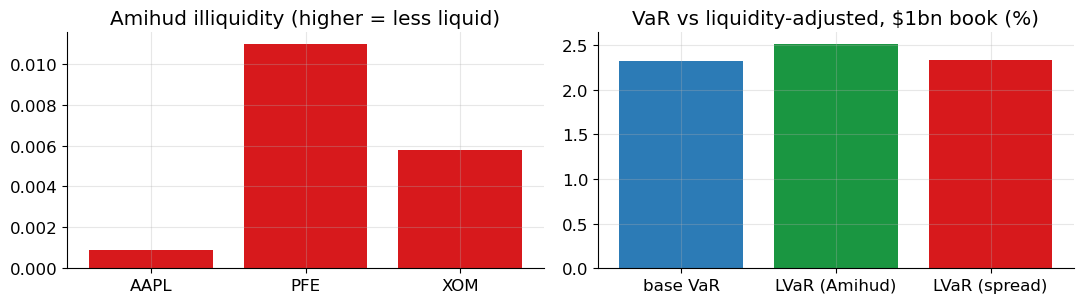

In [7]:
oh = pd.read_csv('a2_ohlcv.csv', index_col=0, parse_dates=True)
close  = oh[[f'close_{s}'  for s in STOCKS]]; close.columns  = STOCKS
volume = oh[[f'volume_{s}' for s in STOCKS]]; volume.columns = STOCKS
high   = oh[[f'high_{s}'   for s in STOCKS]]; high.columns   = STOCKS
low    = oh[[f'low_{s}'    for s in STOCKS]]; low.columns    = STOCKS
ret    = np.log(close/close.shift(1))

dollar_vol = (close * volume).replace(0, np.nan)
amihud = (ret.abs() / dollar_vol).mean() * 1e9
adv    = dollar_vol.mean()

def corwin_schultz_spread(high_s, low_s):
    h, l = high_s.values.astype(float), low_s.values.astype(float)
    h2, l2 = np.maximum(h[:-1], h[1:]), np.minimum(l[:-1], l[1:])
    beta  = (np.log(h[:-1]/l[:-1]))**2 + (np.log(h[1:]/l[1:]))**2
    gamma_ = (np.log(h2/l2))**2
    denom = 3 - 2*np.sqrt(2)
    alpha = (np.sqrt(2*beta) - np.sqrt(beta))/denom - np.sqrt(gamma_/denom)
    spread = 2*(np.exp(alpha) - 1) / (1 + np.exp(alpha))
    return pd.Series(np.where(alpha < 0, 0.0, spread), index=high_s.index[1:]), alpha

cs_df, cs_alpha = {}, {}
for s in STOCKS:
    cs_df[s], cs_alpha[s] = corwin_schultz_spread(high[s], low[s])
cs_df = pd.DataFrame(cs_df)

HALF_SPREAD = {'AAPL': 0.0001/2, 'PFE': 0.0006/2, 'XOM': 0.0003/2}

liq = pd.DataFrame({'Amihud (x1e9)': [f'{amihud[s]:.4f}' for s in STOCKS],
                    'Avg $vol (bn)': [f'{adv[s]/1e9:.2f}' for s in STOCKS],
                    'CS spread (bp)': [f'{cs_df[s].mean()*1e4:.1f}' for s in STOCKS],
                    'CS median (bp)': [f'{cs_df[s].median()*1e4:.1f}' for s in STOCKS],
                    'CS days floored at 0': [f'{(cs_alpha[s] < 0).mean():.0%}' for s in STOCKS],
                    'Quoted half-spread (bp)': [f'{HALF_SPREAD[s]*1e4:.1f}' for s in STOCKS]},
                   index=STOCKS)
print(liq.to_string())
print('\nSanity check: a real AAPL quoted spread is well under 1bp, so the CS mean of '
      f"{cs_df['AAPL'].mean()*1e4:.0f}bp is far too wide and CS does not rank the three names.")
print('I keep CS as a diagnostic and charge liquidity off Amihud instead.')

illiq_raw = (ret.abs() / dollar_vol).mean()

def amihud_liq_cost(book_value):
    return book_value * sum(W[i]**2 * illiq_raw[s] for i, s in enumerate(STOCKS))

BOOK        = 1_000_000_000
spread_cost = sum(W[i]*HALF_SPREAD[s] for i, s in enumerate(STOCKS))
amihud_cost = amihud_liq_cost(BOOK)
LVAR_SPREAD = var_base + spread_cost
LVAR        = var_base + amihud_cost

print(f'\nOn a ${BOOK/1e9:.0f}bn book:')
print(f'  Base VaR:                               {var_base*100:.2f}%')
print(f'  Liquidity-adjusted VaR (my own Amihud): {LVAR*100:.2f}%   (cost {amihud_cost*100:.3f}%)')
print(f'  Liquidity-adjusted VaR (quoted spread): {LVAR_SPREAD*100:.2f}%   (cost {spread_cost*100:.3f}%)')

print('\nAmihud is mean |return| per dollar of volume, so it scales with the position')
print('while a quoted spread does not:')
print(f"  {'book':>9}{'Amihud cost':>13}{'LVaR':>8}{'quoted-spread LVaR':>21}")
for PORT in [10e6, 100e6, BOOK]:
    c = amihud_liq_cost(PORT)
    print(f'  ${PORT/1e6:>7.0f}M{c*100:>12.3f}%{(var_base+c)*100:>7.2f}%{LVAR_SPREAD*100:>20.2f}%')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(STOCKS, [amihud[s] for s in STOCKS], color=RED)
ax[0].set_title('Amihud illiquidity (higher = less liquid)')
ax[1].bar(['base VaR', 'LVaR (Amihud)', 'LVaR (spread)'], [var_base*100, LVAR*100, LVAR_SPREAD*100],
          color=[BLUE, GREEN, RED])
ax[1].set_title(f'VaR vs liquidity-adjusted, ${BOOK/1e9:.0f}bn book (%)')
plt.tight_layout(); plt.show()

Unwinding the same $1000M block in each name, never trading more than 20% of a day's volume.
The stressed regime cuts volume to 40% of normal, doubles daily volatility
and triples the spread:

            ADV ($bn/day)   20% of ADV   days   half-spread      impact   timing risk       total  % of block
-------------------------------------------------------------------------------------------------------------
 AAPL norm  $       13.11  $     2622M      1  $       0.05M  $     4.56M  $      22.17M  $    26.78M      2.68%
  PFE norm  $        1.22  $      243M      5  $       0.30M  $     6.17M  $      45.71M  $    52.19M      5.22%


  XOM norm  $        2.33  $      465M      3  $       0.15M  $     5.55M  $      34.10M  $    39.80M      3.98%
-------------------------------------------------------------------------------------------------------------
 AAPL stre  $        5.24  $     1049M      1  $       0.15M  $    14.42M  $      44.34M  $    58.91M      5.89%
  PFE stre  $        0.49  $       97M     11  $       0.90M  $    13.16M  $     135.60M  $   149.66M     14.97%
  XOM stre  $        0.93  $      186M      6  $       0.45M  $    12.41M  $      96.46M  $   109.32M     10.93%
-------------------------------------------------------------------------------------------------------------

Normally PFE takes 5 days to exit vs 1 for AAPL, and costs 1.9x as much to get out of.
The half-spread is 174x too small to describe PFE's real exit cost.

In the stressed regime PFE takes 11 days and costs 14.97% of the block, 2.9x the normal cost, while AAPL still clears in 1 day at 5.89%.
So the gap between my most and lea

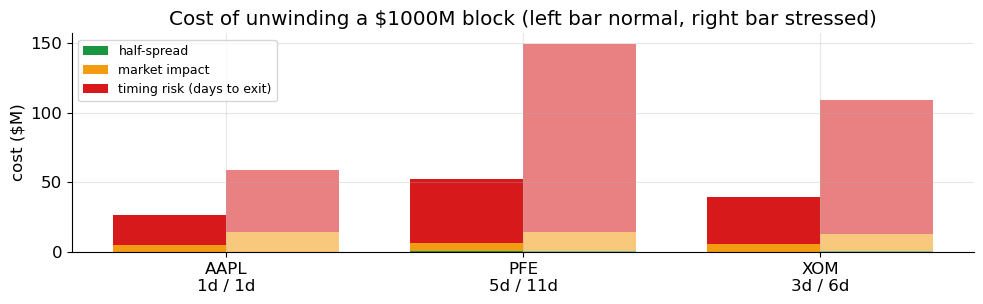

In [8]:
BLOCK, PARTIC_MAX, ETA = BOOK, 0.20, 1.0
z_liq = stats.norm.ppf(0.99)
adv_252 = (close * volume).tail(252).mean()
REGIMES = [('normal', 1.0, 1.0, 1.0), ('stressed', 0.4, 2.0, 3.0)]

print(f'Unwinding the same ${BLOCK/1e6:.0f}M block in each name, never trading more than '
      f'{PARTIC_MAX:.0%} of a day\'s volume.')
print('The stressed regime cuts volume to 40% of normal, doubles daily volatility')
print('and triples the spread:\n')
hdr = (f"{'':>10}  {'ADV ($bn/day)':>13}  {'20% of ADV':>11}  {'days':>5}  {'half-spread':>12}  "
       f"{'impact':>10}  {'timing risk':>12}  {'total':>10}  {'% of block':>10}")
print(hdr); print('-'*len(hdr))
endo = {}
for regime, vol_mult, sigma_mult, spread_mult in REGIMES:
    for s in STOCKS:
        sigma_d = ret[s].std() * sigma_mult
        hs      = HALF_SPREAD[s] * spread_mult
        advd    = adv_252[s] * vol_mult
        T       = max(1.0, np.ceil(BLOCK / (PARTIC_MAX*advd)))
        x       = (BLOCK/advd) / T
        spread_cost = BLOCK * hs
        impact      = BLOCK * ETA * sigma_d * np.sqrt(x)
        timing      = z_liq * sigma_d * BLOCK * np.sqrt(T/3.0)
        tot         = spread_cost + impact + timing
        endo[(regime, s)] = dict(T=T, spread=spread_cost, impact=impact, timing=timing, total=tot)
        print(f'{s+" "+regime[:4]:>10}  ${advd/1e9:>12.2f}  ${PARTIC_MAX*advd/1e6:>9.0f}M  '
              f'{int(T):>5}  ${spread_cost/1e6:>11.2f}M  ${impact/1e6:>9.2f}M  '
              f'${timing/1e6:>11.2f}M  ${tot/1e6:>9.2f}M  {tot/BLOCK:>9.2%}')
    print('-'*len(hdr))

n_pfe, n_aapl = endo[('normal', 'PFE')], endo[('normal', 'AAPL')]
s_pfe, s_aapl = endo[('stressed', 'PFE')], endo[('stressed', 'AAPL')]
print(f"\nNormally PFE takes {int(n_pfe['T'])} days to exit vs {int(n_aapl['T'])} for AAPL, and costs "
      f"{n_pfe['total']/n_aapl['total']:.1f}x as much to get out of.")
print(f"The half-spread is {n_pfe['total']/n_pfe['spread']:.0f}x too small to describe "
      f"PFE's real exit cost.")
print(f"\nIn the stressed regime PFE takes {int(s_pfe['T'])} days and costs "
      f"{s_pfe['total']/BLOCK:.2%} of the block, {s_pfe['total']/n_pfe['total']:.1f}x the normal cost, "
      f"while AAPL still clears in {int(s_aapl['T'])} day at {s_aapl['total']/BLOCK:.2%}.")
print(f"So the gap between my most and least liquid name widens from "
      f"{n_pfe['total']/n_aapl['total']:.1f}x to {s_pfe['total']/s_aapl['total']:.1f}x "
      f"exactly when I would be forced to sell.")

fig, ax = plt.subplots(figsize=(10, 3.2))
b = np.arange(len(STOCKS)); w = 0.38
for regime, off, alpha in [('normal', -w/2, 1.0), ('stressed', w/2, 0.55)]:
    sp = np.array([endo[(regime, s)]['spread']/1e6 for s in STOCKS])
    im = np.array([endo[(regime, s)]['impact']/1e6 for s in STOCKS])
    tm = np.array([endo[(regime, s)]['timing']/1e6 for s in STOCKS])
    lab = ['half-spread', 'market impact', 'timing risk (days to exit)'] if regime == 'normal' \
        else [None, None, None]
    ax.bar(b+off, sp, w, label=lab[0], color=GREEN, alpha=alpha)
    ax.bar(b+off, im, w, bottom=sp, label=lab[1], color=GOLD, alpha=alpha)
    ax.bar(b+off, tm, w, bottom=sp+im, label=lab[2], color=RED, alpha=alpha)
ax.set_xticks(b)
ax.set_xticklabels([f'{s}\n{int(endo[("normal", s)]["T"])}d / {int(endo[("stressed", s)]["T"])}d'
                    for s in STOCKS])
ax.set_ylabel('cost ($M)')
ax.set_title(f'Cost of unwinding a ${BLOCK/1e6:.0f}M block (left bar normal, right bar stressed)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** PFE is the least liquid, an Amihud ratio of 0.011 against AAPL's 0.0009. On a $1bn book Amihud charges 0.196%, lifting my VaR from 2.32% to 2.52%, while a half-spread charges only 0.017% and says 2.34%. I take Amihud because it knows my size, the same names costing 0.002% on a $10M book and 0.196% on $1bn, crossing near $100M, so a spread charge fits one book size.

Corwin-Schultz failed outright, AAPL at 43bp against a real spread under 1bp because it reads the daily high-low range, which for tick-tight names is volatility and gaps not the bid-ask bounce. Half its days floor a negative alpha at zero, so AAPL's 10bp median against a 43bp mean is noise.

Unwinding a $1bn block name by name is worse. AAPL is gone in a day, PFE takes 5 because 20% of its volume is only about $243M, so PFE's $45.7M timing risk and $6.2M impact against a $0.3M half-spread cost 5.22% of the block versus AAPL's 2.68%. That timing already sits in my base VaR. Under stress (volume at 40%, double volatility, triple spreads) PFE takes 11 days and 14.97% while AAPL clears in a day at 5.89%, so my easiest-to-hardest gap widens from 1.9x to 2.5x, the diversification I thought I had thinning out where I would lean on it.

## 5 · Operational-loss distribution

My parameters are judgemental. A large-cap non-financial faces a handful of material events a year across product liability, litigation, cyber and environmental, so I take 3 a year, a $5M median event, and sigma 1.5 for a tail reaching the billions these firms operate in.

Frequency: Poisson(lambda=3.0)  |  Severity: lognormal, median $5M, mean $15.4M
Expected annual op loss:  $46.1M
99% annual op loss:       $342M
99.9% annual op loss:     $876M   ->  Op capital (99.9% - EL): $830M

Shape of the annual loss distribution:
  skew 9.92  |  excess kurtosis 234.5  (Normal = 0 for both)
  99.9% / 99%   ratio: 2.56
  99.9% / mean  ratio: 19.0
  Normal approx 99.9%: $294M vs simulated $876M -> a Normal understates the 99.9% loss by 66%
  and understates capital (99.9% - EL) by 70%

Where a real settlement lands in my distribution:
  Pfizer paid $2.3bn over Bextra in 2009. That single event sits at my 99.993th percentile,
  a 1-in-13,889-year total, against a worst simulated year of $4,310M in a million.
  My model gives a year that bad a 0.0072% chance.


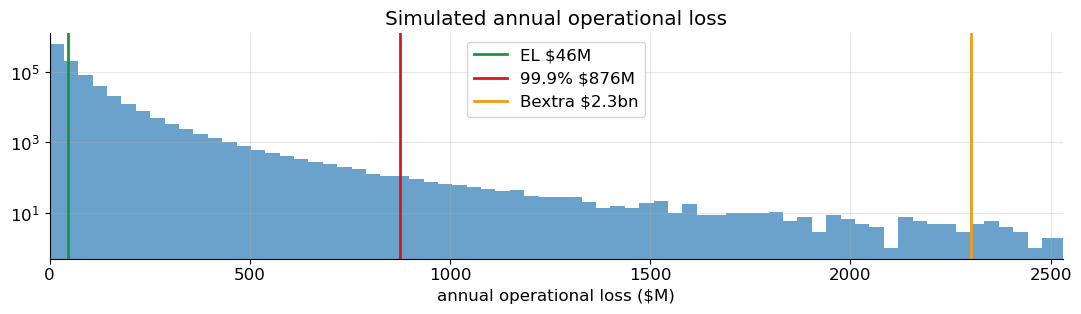

In [9]:
LAMBDA, MU_SEV, SIG_SEV = 3.0, np.log(5e6), 1.5
g = np.random.default_rng(123); YEARS = 1_000_000
counts = g.poisson(LAMBDA, YEARS)
sev    = g.lognormal(MU_SEV, SIG_SEV, counts.sum())
annual = np.bincount(np.repeat(np.arange(YEARS), counts), weights=sev, minlength=YEARS)

mean_sev = np.exp(MU_SEV + 0.5*SIG_SEV**2)
EL_OP  = annual.mean()
OP99   = np.percentile(annual, 99)
OP999  = np.percentile(annual, 99.9)
print(f'Frequency: Poisson(lambda={LAMBDA})  |  Severity: lognormal, median '
      f'${np.exp(MU_SEV)/1e6:.0f}M, mean ${mean_sev/1e6:.1f}M')
print(f'Expected annual op loss:  ${EL_OP/1e6:.1f}M')
print(f'99% annual op loss:       ${OP99/1e6:.0f}M')
print(f'99.9% annual op loss:     ${OP999/1e6:.0f}M   ->  Op capital (99.9% - EL): '
      f'${(OP999-EL_OP)/1e6:.0f}M')

normal_999 = annual.mean() + norm.ppf(0.999)*annual.std()
print(f'\nShape of the annual loss distribution:')
print(f'  skew {skew(annual):.2f}  |  excess kurtosis {kurtosis(annual):.1f}  '
      f'(Normal = 0 for both)')
print(f'  99.9% / 99%   ratio: {OP999/OP99:.2f}')
print(f'  99.9% / mean  ratio: {OP999/EL_OP:.1f}')
print(f'  Normal approx 99.9%: ${normal_999/1e6:.0f}M vs simulated ${OP999/1e6:.0f}M '
      f'-> a Normal understates the 99.9% loss by {100*(1-normal_999/OP999):.0f}%')
print(f'  and understates capital (99.9% - EL) by '
      f'{100*(1-(normal_999-EL_OP)/(OP999-EL_OP)):.0f}%')

BEXTRA = 2.3e9
pct_bextra = (annual < BEXTRA).mean()*100
print(f'\nWhere a real settlement lands in my distribution:')
print(f'  Pfizer paid ${BEXTRA/1e9:.1f}bn over Bextra in 2009. That single event sits at my '
      f'{pct_bextra:.3f}th percentile,')
print(f'  a 1-in-{1/(1-pct_bextra/100):,.0f}-year total, against a worst simulated year of '
      f'${annual.max()/1e6:,.0f}M in a million.')
print(f'  My model gives a year that bad a {100-pct_bextra:.4f}% chance.')

fig, ax = plt.subplots(figsize=(11, 3.3))
ax.hist(annual/1e6, bins=120, color=BLUE, alpha=.7)
ax.axvline(EL_OP/1e6, color=GREEN, lw=2, label=f'EL ${EL_OP/1e6:.0f}M')
ax.axvline(OP999/1e6, color=RED, lw=2, label=f'99.9% ${OP999/1e6:.0f}M')
ax.axvline(BEXTRA/1e6, color=GOLD, lw=2, label=f'Bextra ${BEXTRA/1e9:.1f}bn')
ax.set_xlim(0, BEXTRA/1e6*1.1); ax.set_yscale('log')
ax.set_xlabel('annual operational loss ($M)')
ax.set_title('Simulated annual operational loss'); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
def lda_capital(lam, mu, sg, years=YEARS, seed=123):
    gg = np.random.default_rng(seed)
    c  = gg.poisson(lam, years)
    sv = gg.lognormal(mu, sg, c.sum())
    a  = np.bincount(np.repeat(np.arange(years), c), weights=sv, minlength=years)
    return np.percentile(a, 99.9) - a.mean()

base = lda_capital(LAMBDA, MU_SEV, SIG_SEV)
print('Sensitivity of the 99.9% capital number to my assumptions:\n')
print(f"  {'assumption':<28}{'capital':>12}{'vs base':>10}")
print('  ' + '-'*48)
for lam in [1.5, 3.0, 6.0]:
    c = lda_capital(lam, MU_SEV, SIG_SEV)
    print(f"  {'lambda = ' + str(lam) + ' events/yr':<28}${c/1e6:>10.0f}M{c/base:>9.2f}x")
for sg in [1.0, 1.5, 2.0, 2.5]:
    c = lda_capital(LAMBDA, MU_SEV, sg)
    mean_sg = np.exp(MU_SEV + 0.5*sg**2)
    print(f"  {'severity sigma = ' + str(sg):<28}${c/1e6:>10.0f}M{c/base:>9.2f}x"
          f"   (mean event ${mean_sg/1e6:.1f}M)")

print('')
print('Raising sigma also raises the mean event, so the rows above mix a fatter tail')
print('with a bigger average loss. Holding the mean event fixed at $15.4M isolates')
print('the tail shape on its own:')
for sg in [1.0, 1.5, 2.0, 2.5]:
    mu_fixed = MU_SEV + 0.5*(SIG_SEV**2 - sg**2)
    c = lda_capital(LAMBDA, mu_fixed, sg)
    print(f"  {'sigma = ' + str(sg) + ' (mean held)':<28}${c/1e6:>10.0f}M{c/base:>9.2f}x"
          f"   (mean event ${np.exp(mu_fixed + 0.5*sg**2)/1e6:.1f}M)")

def business_indicator_component(BI):
    b1, b2 = 1e9, 30e9
    if BI <= b1: return 0.12*BI
    if BI <= b2: return 0.12*b1 + 0.15*(BI - b1)
    return 0.12*b1 + 0.15*(b2 - b1) + 0.18*(BI - b2)

def internal_loss_multiplier(LC, BIC):
    return np.log(np.e - 1 + (LC/BIC)**0.8)

BI  = 20e9
LC  = 15 * EL_OP
print('The SMA is a bank capital rule, so it does not apply to AAPL, PFE or XOM directly.')
print('I run it for a mid-size bank carrying a loss profile like theirs, as the')
print('standardized comparator to the internal model above.')
BIC = business_indicator_component(BI)
ILM = internal_loss_multiplier(LC, BIC)
print(f'\nBasel SMA (the rule since 2023), for a mid-size bank with BI = ${BI/1e9:.0f}bn:')
print(f'  BIC ${BIC/1e9:.2f}bn  x  ILM {ILM:.3f}  =  SMA capital ${BIC*ILM/1e9:.2f}bn')
print(f'  My 99.9% economic capital: ${(OP999-EL_OP)/1e9:.2f}bn  '
      f'-> SMA charges {BIC*ILM/(OP999-EL_OP):.1f}x my internal model')

Sensitivity of the 99.9% capital number to my assumptions:

  assumption                       capital   vs base
  ------------------------------------------------


  lambda = 1.5 events/yr      $       620M     0.75x
  lambda = 3.0 events/yr      $       830M     1.00x


  lambda = 6.0 events/yr      $      1092M     1.32x


  severity sigma = 1.0        $       161M     0.19x   (mean event $8.2M)
  severity sigma = 1.5        $       830M     1.00x   (mean event $15.4M)
  severity sigma = 2.0        $      4485M     5.40x   (mean event $36.9M)


  severity sigma = 2.5        $     24484M    29.50x   (mean event $113.8M)

Raising sigma also raises the mean event, so the rows above mix a fatter tail
with a bigger average loss. Holding the mean event fixed at $15.4M isolates
the tail shape on its own:


  sigma = 1.0 (mean held)     $       301M     0.36x   (mean event $15.4M)
  sigma = 1.5 (mean held)     $       830M     1.00x   (mean event $15.4M)
  sigma = 2.0 (mean held)     $      1870M     2.25x   (mean event $15.4M)


  sigma = 2.5 (mean held)     $      3314M     3.99x   (mean event $15.4M)
The SMA is a bank capital rule, so it does not apply to AAPL, PFE or XOM directly.
I run it for a mid-size bank carrying a loss profile like theirs, as the
standardized comparator to the internal model above.

Basel SMA (the rule since 2023), for a mid-size bank with BI = $20bn:
  BIC $2.97bn  x  ILM 0.708  =  SMA capital $2.10bn
  My 99.9% economic capital: $0.83bn  -> SMA charges 2.5x my internal model


**Interpretation:** My average year loses $46.1M but the 99.9% year loses $876M, so operational capital is about $830M. Skew is 9.9 and excess kurtosis 234 against 0 for a Normal, and a Normal on the same mean and standard deviation puts the 99.9% loss at $294M, understating it by 66% and the capital by 70%. It is not abstract, since Pfizer's $2.3bn 2009 Bextra settlement lands at the 99.993th percentile, one in 13,889 years, so a loss already paid sits too far out, my sigma of 1.5 too thin.

The sensitivity is lopsided. Doubling frequency from 3 to 6 events raises capital 1.32 times, but severity sigma from 1.5 to 2.0 multiplies it 5.4 times and 2.5 multiplies it 29.5 times. That flatters my point, since raising sigma also lifts the mean event from $15.4M to $36.9M, but with the mean fixed capital still moves 2.25 times at 2.0 and 4.0 times at 2.5, tail shape beating frequency by three times not twenty because at the 99.9% quantile my year is basically one event. That least-evidenced parameter sets the answer, why Basel scrapped internal models here, and for a mid-size bank with these losses the SMA charges $2.10bn against my $0.83bn, reading my size, never my tail.

## 6 · Basel, credit, market & operational risk

It rests on expected versus unexpected loss. Expected loss is provisioned, so capital covers only the gap to a bad year, at a confidence level the regulator picks.

Credit is standardized weights off the rating or the IRB Vasicek charge my granular pool matched. It needs a large diversified pool, so my three-name book is the case it cannot see, where almost all risk is one borrower alone and one Gaussian correlation misses what a t factor did to my 99.9% loss.

Market risk gets standardized sensitivities or an internal FRTB track that measures Expected Shortfall not VaR, since a quantile is silent on what sits behind it, the blindness that froze my 99% number on one atom. Its liquidity horizons match my PFE at eleven days under stress, and Basel replaced operational internal models with the SMA my sensitivity table argues for.

My three differ. PFE pulls credit, liquidity and operational risk into one obligor an IRB charge for a diversified pool cannot see, AAPL's size makes its rare default my worst single loss, and XOM only moves my 99.9% once correlation reaches 0.30.

Each model ranked my firms sensibly but none on the level, the half-spread understating PFE's exit by 174 times, so I check the level against something outside the model.